In [1]:
# Task 5: Decision Trees and Random Forests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(data.target_names)

print("\nFirst 5 Rows:")
print(X.head())

Dataset Shape: (569, 30)

Features:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target Classes:
['malignant' 'benign']

First 5 Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38 

In [2]:
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [3]:
# Train Decision Tree Classifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9122807017543859

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



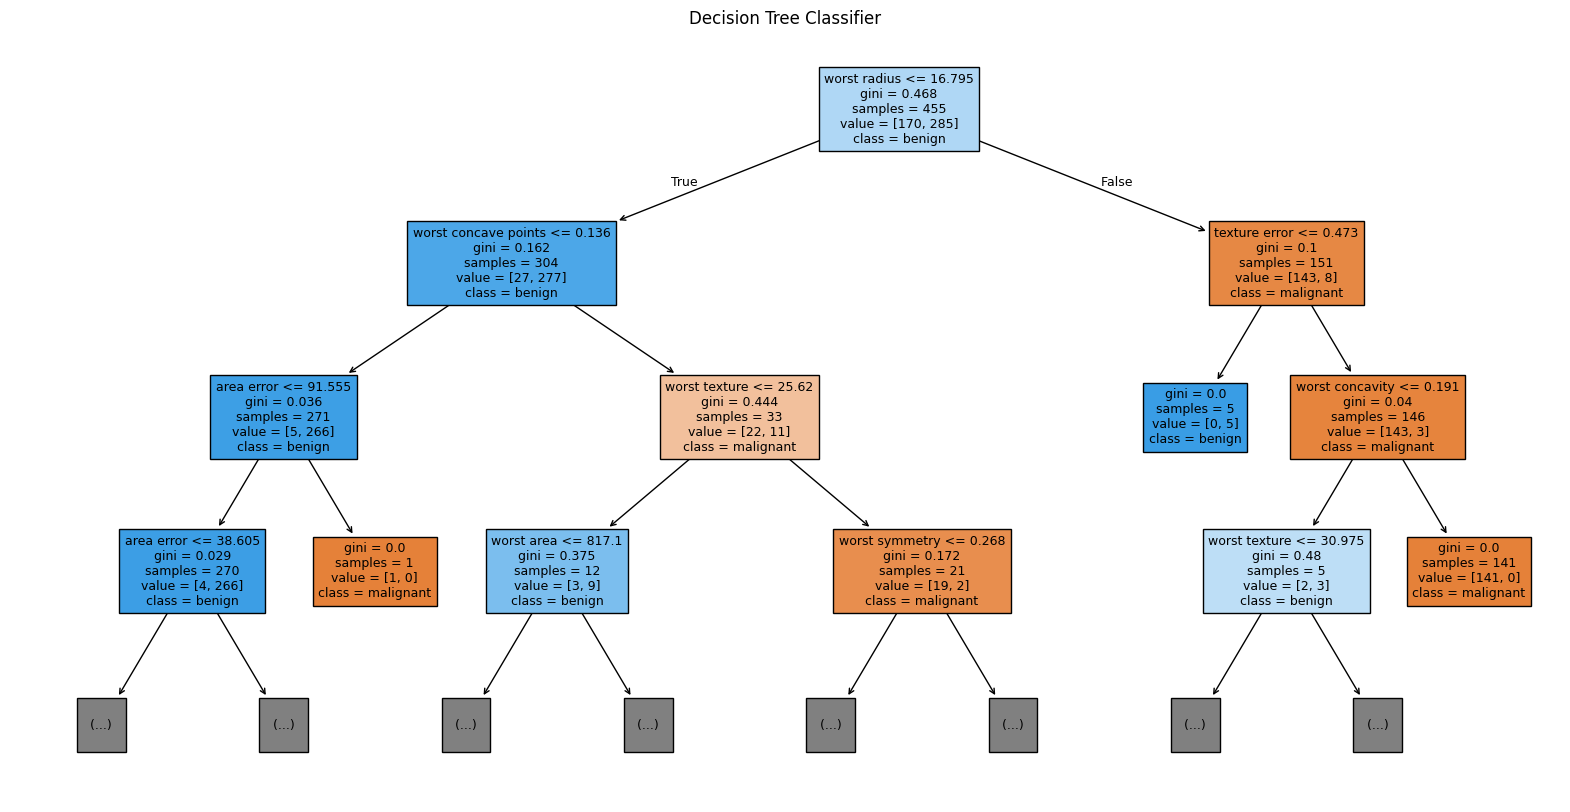

In [4]:
# Visualize Decision Tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree Classifier")
plt.show()

In [5]:
# Analyze overfitting

train_accuracy = dt_model.score(X_train, y_train)
test_accuracy = dt_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9122807017543859


In [6]:
# Decision Tree with controlled depth

dt_depth = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_depth.fit(X_train, y_train)

y_pred_depth = dt_depth.predict(X_test)

depth_accuracy = accuracy_score(y_test, y_pred_depth)

print("Decision Tree (max_depth=5) Accuracy:", depth_accuracy)

Decision Tree (max_depth=5) Accuracy: 0.9210526315789473


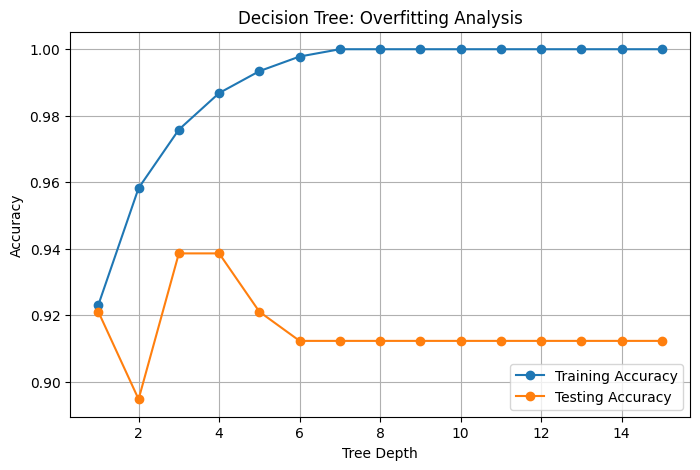

In [7]:
# Compare different tree depths

depths = range(1, 16)

train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(8, 5))

plt.plot(depths, train_scores, marker='o', label="Training Accuracy")
plt.plot(depths, test_scores, marker='o', label="Testing Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Overfitting Analysis")
plt.legend()
plt.grid()
plt.show()

In [8]:
# Train Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.956140350877193

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [9]:
# Compare model accuracy

print("Model Comparison")
print("------------------------")
print("Decision Tree Accuracy :", dt_accuracy)
print("Random Forest Accuracy :", rf_accuracy)

Model Comparison
------------------------
Decision Tree Accuracy : 0.9122807017543859
Random Forest Accuracy : 0.956140350877193


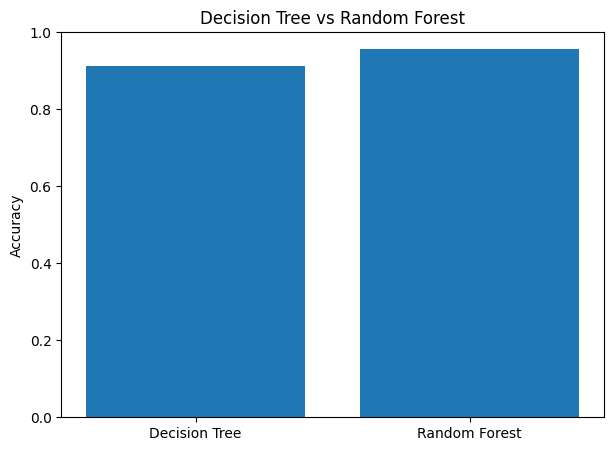

In [10]:
models = ["Decision Tree", "Random Forest"]
accuracies = [dt_accuracy, rf_accuracy]

plt.figure(figsize=(7, 5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Decision Tree vs Random Forest")
plt.ylim(0, 1)

plt.show()

In [11]:
# Feature Importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance.head(10))

Feature Importance:
                 Feature  Importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


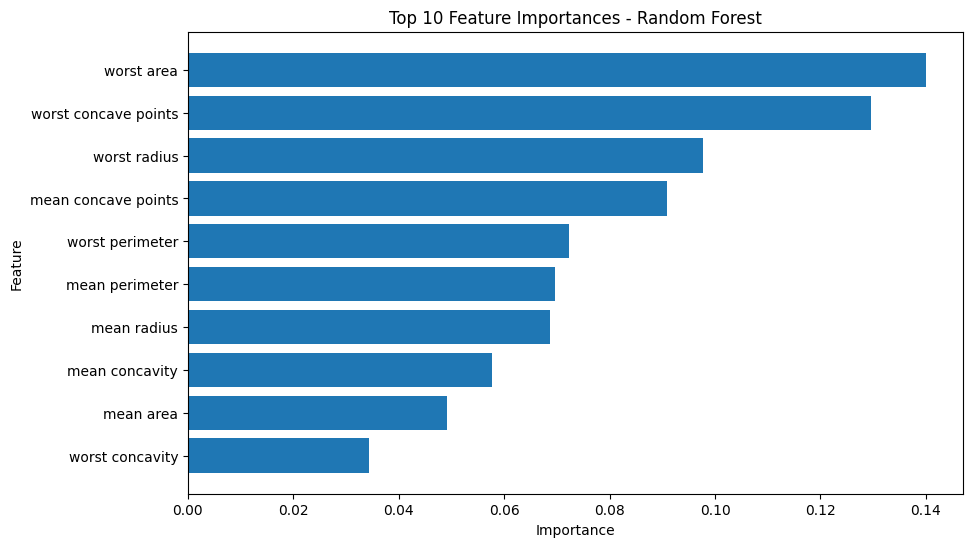

In [12]:
# Plot top 10 important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")

plt.show()

Confusion Matrix:
[[39  3]
 [ 2 70]]


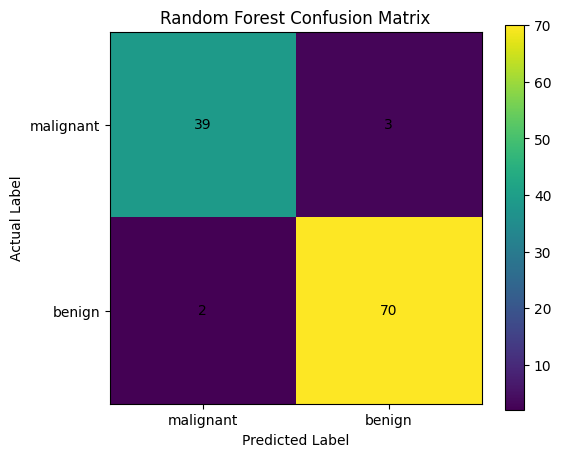

In [13]:
# Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.xticks([0, 1], data.target_names)
plt.yticks([0, 1], data.target_names)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [14]:
# 5-Fold Cross Validation for Decision Tree

dt_cv_scores = cross_val_score(
    dt_depth,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Decision Tree Cross-Validation Scores:")
print(dt_cv_scores)

print("Mean CV Accuracy:", dt_cv_scores.mean())

Decision Tree Cross-Validation Scores:
[0.89473684 0.9122807  0.92982456 0.94736842 0.91150442]
Mean CV Accuracy: 0.91914299021891


In [15]:
# 5-Fold Cross Validation for Random Forest

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("\nRandom Forest Cross-Validation Scores:")
print(rf_cv_scores)

print("Mean CV Accuracy:", rf_cv_scores.mean())


Random Forest Cross-Validation Scores:
[0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]
Mean CV Accuracy: 0.9560937742586555


In [16]:
print("========== FINAL RESULTS ==========")

print(f"Decision Tree Test Accuracy : {dt_accuracy:.4f}")
print(f"Random Forest Test Accuracy : {rf_accuracy:.4f}")

print(f"\nDecision Tree Mean CV Accuracy : {dt_cv_scores.mean():.4f}")
print(f"Random Forest Mean CV Accuracy : {rf_cv_scores.mean():.4f}")

print("\n===================================")

========== FINAL RESULTS ==========
Decision Tree Test Accuracy : 0.9123
Random Forest Test Accuracy : 0.9561

Decision Tree Mean CV Accuracy : 0.9191
Random Forest Mean CV Accuracy : 0.9561



## Conclusion

In this task, Decision Tree and Random Forest classifiers were implemented
using the Breast Cancer Wisconsin dataset.

The Decision Tree model was trained and visualized to understand how
tree-based classification works. Different tree depths were tested to
analyze and control overfitting.

A Random Forest model was then trained using multiple decision trees.
The performance of the Decision Tree and Random Forest models was compared
using test accuracy and cross-validation.

Feature importance from the Random Forest model was also analyzed to
identify the features that contributed most to the predictions.

Overall, Random Forest provides a robust ensemble-based approach and can
reduce the overfitting problem commonly associated with a single decision
tree.

---

